In [1]:
from platform import python_version
print(python_version())

3.11.14


### Cluster with Tahoe or sc-GTP

### Huggingface: tahoebio/Tahoe-x1-embeddings

https://github.com/tahoebio/tahoe-x1

Tahoe-x1: Scaling Perturbation-Trained Single-Cell Foundation Models to 3 Billion Parameters


#### Memory

That's not a general "64 GB isn't enough" — swap is fully exhausted at 2.0G, which means something asked for tens of GB in one allocation. Given where you are in the pipeline, the culprit is almost certainly load_tahoe_de, and the arithmetic says so:

The DE table is ~4.09e9 rows over ~75k conditions × ~54k genes. 

Filtering to pancreas doesn't help much — roughly 
- 6 lines × 379 drugs × ~4 doses × 54k genes ≈ 5e8 rows, 
- materialised in pandas with gene/drug/cell_line_id as object-dtype strings (~200 B/row) before pivot_table ever runs. 
- That's >100 GB. full_Z and consensus_cluster are megabytes by comparison.



In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, ROOT_SRC)


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config
from libs.prism_lib import PRISM
from libs.prism_program_lib import *


from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

### Prism - development

In [8]:
import anndata as ad

prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

prism.root_singc, prism.root_singc.exists()

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



(PosixPath('/home/flavio/uv/perturb_agent/data/single_cell'), True)

### Running prism

In [9]:
verbose=True

res = prism.open_bayesprism(verbose=verbose)
print(len(res.genes))

Loaded /home/flavio/uv/perturb_agent/data/single_cell/deconv.h5ad (8.1 MB)
1918


In [10]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [11]:
res.theta_type.columns

Index(['Acinar cell', 'B cell', 'Ductal cell type 1', 'Endocrine cell', 'Endothelial cell',
       'Fibroblast cell', 'Macrophage cell', 'Stellate cell', 'T cell', 'malignant'],
      dtype='object')

### Ductal cell type 1

"Ductal cell type 1" is the normal-like ductal population and stays in the environment compartment — which is what you want. If both had been mapped to malignant, purity would inflate. Verify with res.tumor_purity.groupby(meta["condition"]).describe(): normals near zero, tumors somewhere in 0.2–0.6.


### Ductal cell type 2

One malignant state means no Ductal cell type 2 subdivision, so subtype_malignant scores Moffitt signatures on a single pooled malignant profile. That still works — it's per-sample expression, so samples can differ — but it won't give you distinct malignant states in θ. For that you'd subcluster Ductal cell type 2 in the AnnData and write finer cell_state labels before calling pseudobulk_reference.

In [12]:
res.cell_type_expression("Ductal cell type 1").shape

(1918, 153)

In [13]:
res.cell_type_expression("Ductal cell type 2").shape

(1918, 153)

### 2. theta is now fixed -> expand Z to every gene

In [14]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file


In [15]:
print(dfn_tumor.shape)
dfn_tumor.head(3)

(60616, 134)


,geneid,symbol,biotype,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,...,T-TCGA-HZ-7289,T-TCGA-3A-A9IN,T-TCGA-3A-A9IS,T-TCGA-2L-AAQM,T-TCGA-3A-A9IR,T-TCGA-3A-A9IV,T-TCGA-3A-A9IO,T-TCGA-2J-AABT,T-TCGA-H6-A45N,T-TCGA-3A-A9IJ
0,ENSG00000000003,TSPAN6,protein_coding,1486,2083,1558,546,1208,648,896,...,2506,442,38,299,77,158,394,659,1294,395
1,ENSG00000000005,TNMD,protein_coding,12,97,15,1,14,2,5,...,2,172,4,2,1,2,14,3,3,0
2,ENSG00000000419,DPM1,protein_coding,1330,1521,1499,986,1388,974,649,...,1638,940,1372,1008,1493,1059,922,839,717,1034


### Bulk - by geneid

In [16]:
df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        gene_key="geneid", force=False, verbose=verbose)

#--- reference geneid --> 
gene_map = prism.load_gene_map("geneid")
print(df_bulk.shape)
df_bulk.head(2)

(27177, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
geneid,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1486,2083,1558,546,1208,648,896,1532,821,1217,...,891,1063,1261,1821,554,1244,977,1576,3738,369
ENSG00000000005,12,97,15,1,14,2,5,6,3,11,...,0,7,2,6,1,1,3,39,4,5


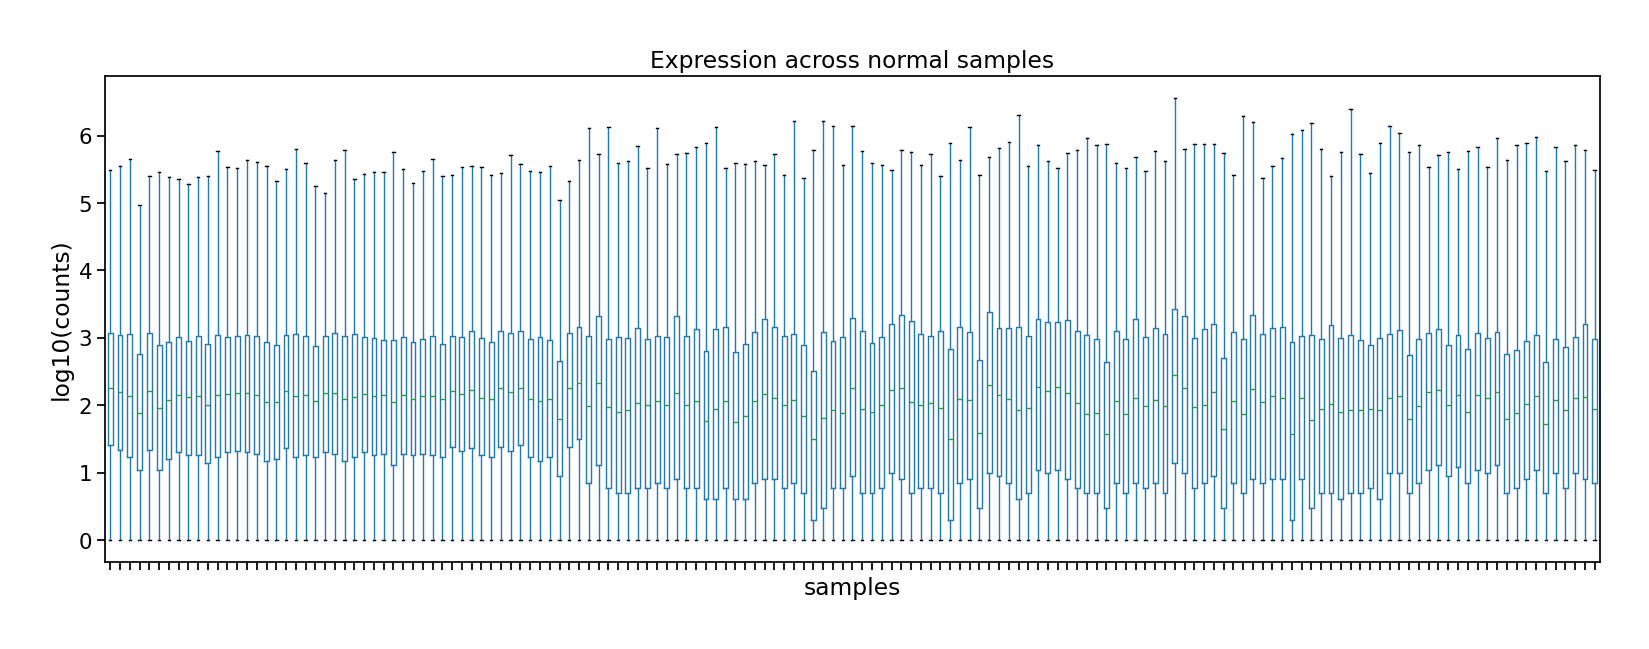

In [17]:
cbio.plot_boxplot_expression(df_bulk, do_log10=True, title = "Expression across normal samples")

### Prism single-cell data reference - Peng 2019

In [18]:
force=False
verbose=True

fname = "count-matrix.txt"
adata = prism.load_matrix(fname=fname, sep=' ', force=force, verbose=verbose)

fname_ad = fname.replace('.txt', '.h5ad')
filename_ad = prism.root_singc / fname_ad
compression = "gzip"


verbose=True
fname_celltype = "all_celltype.txt"
adata_ct = prism.attach_celltypes(adata=adata, fname_celltype=fname_celltype, verbose=verbose)

adata_ct

57,530 cells x 24,005 genes | obs: []
all_celltype.txt columns: ['cluster']
                             cluster
cell.name                           
T1_AAACCTGAGATGTCGG  Fibroblast cell
T1_AAACGGGGTCATGCAT    Stellate cell
T1_AAAGATGCATGTTGAC  Macrophage cell
using type_col='cluster'
barcode overlap: 57,530 / 57,530
cell_type
malignant             11315
Ductal cell type 1    10317
Endothelial cell       9117
Fibroblast cell        6742
Stellate cell          5907
Macrophage cell        5361
T cell                 3660
B cell                 2447
Acinar cell            1935
Endocrine cell          729
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 57530 × 24005
    obs: 'cluster', 'cell_type', 'cell_state'

### Reference

In [19]:
ref, s2t = prism.pseudobulk_reference(adata_ct)

print(ref.shape)
ref.head(3)

(10, 23789)


gene,AL627309.1,AP006222.2,RP11-206L10.3,RP11-206L10.2,RP11-206L10.9,LINC00115,FAM41C,RP11-54O7.3,SAMD11,NOC2L,...,RP11-133N21.10,TMEM5-AS1,RP11-175P13.2,TBC1D4-AS1,RP11-329J18.3,RP11-227G15.2,RP11-686D22.5,KRT222,RP11-799B12.2,CTC-429C10.2
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,64.0,1612.0,42.0,22.0,30.0,214.0,102.0,103.0,1246.0,2337.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,44.0,903.0,25.0,16.0,30.0,162.0,55.0,13.0,112.0,1719.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Macrophage cell,141.0,696.0,81.0,29.0,22.0,182.0,124.0,5.0,35.0,1293.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Bulk symbols

In [20]:
bulk_symbs = pd.read_csv(prism.root_singc / "bulk_matrix.tsv", sep="\t", index_col=0, usecols=[0])

### Get Harmonize

In [21]:
verbose=True

ref_new, df_to_from = prism.get_harmonize_reference_to_ensembl(ref=ref, verbose=verbose)

print(ref_new.shape)
print(df_to_from.status.value_counts())
ref_new.head(2)

Table opened ((10, 17540)) at '/home/flavio/uv/perturb_agent/data/single_cell/ref_new_geneid.tsv'
Table opened ((23789, 5)) at '/home/flavio/uv/perturb_agent/data/single_cell/to_from_table.tsv'
(10, 17540)
status
ok               17540
no_ensembl_id     6249
Name: count, dtype: int64


,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [22]:
df_to_from2 = df_to_from[~pd.isnull(df_to_from.geneid)]
df_to_from2.head(3)

,ref_symbol,current_symbol,geneid,status,renamed
5,LINC00115,LINC00115,ENSG00000225880,ok,False
8,SAMD11,SAMD11,ENSG00000187634,ok,False
9,NOC2L,NOC2L,ENSG00000188976,ok,False


### gene_subset

In [23]:
gene_subset = prism.select_genes(ref_new)
len(gene_subset)

1918

### get bayesprism

In [24]:
verbose=True
force=False

meta_desc = dict(reference="Peng2019_CRA001160",
              cohorts=["TCGA-PAAD", "CPTAC3"],
              strand="unstranded",
              method="InstaPrism")

res = prism.run_bayesprism(df_bulk=df_bulk, ref=ref_new, state_to_type=s2t,
                           gene_subset=gene_subset, meta_desc=meta_desc, force=False, verbose=verbose)

type(res)

Loaded /home/flavio/uv/perturb_agent/data/single_cell/deconv.h5ad (8.1 MB)


libs.prism_lib.DeconvResult

### Zfull

In [25]:
res.Z.shape, df_bulk.shape, ref_new.shape

((153, 10, 1918), (27177, 153), (10, 17540))

In [26]:
Zfull, gfull = prism.full_Z(res, df_bulk, ref_new)
print(Zfull.shape)

(153, 10, 17540)


### Counts per cell

In [27]:
dic = {}

for cell_state in res.states:
    Z = prism.state_expression(Zfull, gfull, res, cell_state)
    dic[cell_state] = Z
    print(cell_state, Z.shape)


Fibroblast cell (17540, 153)
Stellate cell (17540, 153)
Macrophage cell (17540, 153)
Endothelial cell (17540, 153)
T cell (17540, 153)
B cell (17540, 153)
Ductal cell type 2 (17540, 153)
Endocrine cell (17540, 153)
Ductal cell type 1 (17540, 153)
Acinar cell (17540, 153)


In [28]:
i=0
key = list(dic.keys())[i]

print(key)
Z = dic[key]
Z.head(3)

Fibroblast cell


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000003,32.066,58.012,43.613,32.366,34.058,31.881,35.654,54.328,30.481,40.203,...,NaN,16.647,16.364,NaN,NaN,NaN,27.003,NaN,53.037,NaN
ENSG00000000005,0.156,1.310,0.271,0.029,0.172,0.058,0.136,0.085,0.060,0.182,...,NaN,0.124,0.020,NaN,NaN,NaN,0.119,NaN,0.035,NaN
ENSG00000000419,41.234,43.095,42.380,62.828,42.398,43.955,25.719,43.317,42.273,46.569,...,NaN,25.995,36.263,NaN,NaN,NaN,21.046,NaN,32.622,NaN


### Ductal 2 - malignant

In [29]:
# has normal samples
Zmal = prism.state_expression(Zfull, gfull, res, "Ductal cell type 2")
print(Zmal.shape)
Zmal.head(3)

(17540, 153)


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
ENSG00000000003,30.065,55.029,40.439,32.081,32.77,31.182,33.480,52.445,28.622,41.104,...,NaN,20.901,18.993,NaN,NaN,NaN,39.159,NaN,54.487,NaN
ENSG00000000005,0.035,0.297,0.060,0.007,0.04,0.013,0.031,0.020,0.014,0.045,...,NaN,0.037,0.005,NaN,NaN,NaN,0.041,NaN,0.009,NaN
ENSG00000000419,34.732,36.725,35.302,55.946,36.65,38.623,21.696,37.567,35.662,42.774,...,NaN,29.322,37.812,NaN,NaN,NaN,27.419,NaN,30.108,NaN


In [30]:
ok = np.sum([1 if geneid in ref_new.columns.to_list() else 0 for geneid in df_bulk.index])
ok, len(df_bulk), ref_new.shape[1]

(17540, 27177, 17540)

In [31]:
bt = gene_map.reindex(df_bulk.index)["biotype"]
pd.crosstab(bt, df_bulk.index.isin(ref_new.columns), normalize="index").round(3)

col_0,False,True
biotype,,
lncRNA,0.884,0.116
miRNA,0.997,0.003
protein_coding,0.053,0.947


In [32]:
ref_new.head(3)

,ENSG00000225880,ENSG00000187634,ENSG00000188976,ENSG00000187961,ENSG00000187583,ENSG00000188290,ENSG00000187608,ENSG00000188157,ENSG00000237330,ENSG00000131591,...,ENSG00000167355,ENSG00000184999,ENSG00000235910,ENSG00000157335,ENSG00000257008,ENSG00000166573,ENSG00000268182,ENSG00000254453,ENSG00000226245,ENSG00000213424
cell_state,,,,,,,,,,,,,,,,,,,,,
Fibroblast cell,214.0,1246.0,2337.0,115.0,90.0,4981.0,18665.0,1758.0,11.0,274.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Stellate cell,162.0,112.0,1719.0,52.0,26.0,9730.0,16767.0,1611.0,2.0,172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
Macrophage cell,182.0,35.0,1293.0,66.0,47.0,918.0,19924.0,825.0,9.0,157.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### MalignantCluster

In [33]:
import importlib, libs.prism_malig_lib as pml
importlib.reload(pml)
print(pml.__version__)

0.35.0


In [34]:
root_mprog_cluster = cbio.root_mprog_disease / 'cluster'
mal_cell_name = "Ductal cell type 2"
kmax = 8
no_decouple = True
is_tahoe = True


mc = pml.MalignantCluster(prism=prism, res=res, 
                          df_bulk=df_bulk, ref=ref_new, 
                          root_mprog_cluster = root_mprog_cluster,
                          mal_cell_name = mal_cell_name,
                          organ="Pancreas")

mc

### pc_theta_pearson and pc_theta_pearson_raw

**The computation.** Run PCA on the samples × genes matrix, take the first 5 principal components, and correlate each PC's sample scores with `theta_mal` (each sample's malignant fraction). `pcs[:, i]` is one number per sample for PC *i*; `theta_mal.values` is one number per sample. `np.corrcoef(...)[0,1]` pulls the off-diagonal — the Pearson r between them.

You get 5 numbers, one per PC. Each answers: *does this dominant axis of variation track tumour purity?*

**The two versions:**

| | matrix | meaning |
|---|---|---|
| `pc_theta_pearson_raw` | `logx` — log2-CPM before decoupling | how much purity is in the data |
| `pc_theta_pearson` | `Xc` — the matrix you actually cluster | how much purity survives into the analysis |

With `decouple_purity=False` they're the same matrix, so the numbers match — your `[-0.596, -0.205, 0.227, -0.359, -0.158]` versus `[-0.596, -0.205, 0.228, -0.359, -0.159]`. The tiny differences are HVG selection, which happens between the two calls.

With `decouple_purity=True`, `Xc` holds residuals from regressing on `theta_mal`, and residuals are **orthogonal to their regressors by construction**. So `pc_theta_pearson` becomes ~1e-15 — pure floating-point noise. It proves the arithmetic worked, nothing about your data. That's why 0.20.1 added the `_raw` version and the `pc_theta_note`: I originally had you reading a number that can only ever be zero.

**Your actual numbers matter.** PC1 at r = −0.596 means ~36% of the leading component's variance is shared with purity, and PC4 at −0.359 adds more. The sign says low-purity samples score high on PC1. Since `X` is what produced the consensus clustering, the 134-gene tumour axis, and the 6/119 splits, purity is a live confound in all of them.

Which is the concrete reason to run `decouple_purity=True` and compare — with the standing caveat that basal-like PDAC is genuinely lower-purity, so some of that r is biology you'd be deleting.

In [35]:
X, diag = mc.prepare_malignant_matrix(decouple_purity=False, 
                                      keep_genes=mc.program1_panel, drop_pattern=r"^N-")

print("Limited by n_hvg\n")
print(X.shape)
X.head(3)

excluded 22/153 samples by keep_samples/drop_pattern
Limited by n_hvg

(118, 2000)


,ENSG00000001084,ENSG00000001561,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,...,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278259,ENSG00000278535,ENSG00000278540
T-C3L-02890,6.780,5.736,7.171,5.541,8.460,7.229,3.217,7.004,6.726,7.630,...,6.132,6.505,8.483,5.027,4.268,2.718,4.797,7.108,3.834,7.867
T-C3L-03635,6.269,5.560,7.215,6.130,8.503,8.109,4.257,6.930,7.244,7.363,...,6.472,5.909,6.709,6.371,3.522,3.931,4.802,7.070,4.182,8.450
T-C3L-02701,5.989,7.098,7.601,7.242,8.451,7.274,4.592,7.107,7.048,6.365,...,6.274,5.258,7.830,4.836,4.575,3.923,5.229,7.101,4.260,7.952


In [36]:
diag["pc_theta_pearson"]   # PC-vs-theta_mal

[-0.6396090543738907,
 -0.2276638429648091,
 0.23466199008920524,
 -0.31802711358295094,
 -0.1304660320632882]

In [37]:
diag["pc_theta_pearson_raw"]   # PC-vs-theta_mal on logx (pre-decoupling)

[-0.6396006347034379,
 -0.22759697895785228,
 0.234733517780474,
 -0.3180939313449109,
 -0.13072691091580757]

In [38]:
diag["pc_theta_note"]          # warns the decoupled version is ~0 by construction

'decouple_purity=False, so pc_theta_pearson and pc_theta_pearson_raw are the same matrix and both are informative: a large |r| on an early PC means the clustering is tracking tumour purity.'

In [39]:
diag["sample_mean_expr"]       # Xc.mean(axis=1) per sample

T-C3L-02890       6.171
T-C3L-03635       6.080
T-C3L-02701       6.174
T-C3L-04072       5.682
T-C3L-00589       6.050
                  ...  
T-TCGA-2L-AAQM    4.425
T-TCGA-3A-A9IR    4.159
T-TCGA-3A-A9IV    4.590
T-TCGA-2J-AABT    6.073
T-TCGA-H6-A45N    6.231
Length: 118, dtype: float32

In [40]:
diag["sample_total_Z"]         # ms.Z.sum(axis=1) per sample

T-C3L-02890       1.000e+06
T-C3L-03635       1.000e+06
T-C3L-02701       1.000e+06
T-C3L-04072       1.000e+06
T-C3L-00589       1.000e+06
                    ...    
T-TCGA-2L-AAQM    1.000e+06
T-TCGA-3A-A9IR    1.000e+06
T-TCGA-3A-A9IV    1.000e+06
T-TCGA-2J-AABT    1.000e+06
T-TCGA-H6-A45N    1.000e+06
Length: 118, dtype: float32

In [41]:
diag["theta_excluded"]

count    15.000
mean      0.291
std       0.416
min       0.000
25%       0.002
50%       0.066
75%       0.563
max       0.985
Name: Ductal cell type 2, dtype: float64

In [42]:
diag["theta_kept"]

count    130.000
mean       0.345
std        0.256
min        0.000
25%        0.145
50%        0.298
75%        0.496
max        1.000
Name: Ductal cell type 2, dtype: float64

### Inspecting vars

In [43]:
import inspect
print(pml.__version__)
print("drop_pattern" in inspect.signature(mc.prepare_malignant_matrix).parameters)

0.35.0
True


In [44]:
info = mc.inspect_de_schema(genes=X.columns)
print(info.keys())
info["columns"]

dict_keys(['shard_file', 'file_mb', 'total_rows_in_shard', 'columns', 'dtypes', 'head', 'distinct_gene_name', 'n_distinct_gene_name', 'distinct_baseMean', 'n_distinct_baseMean', 'distinct_log2FoldChange', 'n_distinct_log2FoldChange', 'distinct_lfcSE', 'n_distinct_lfcSE', 'distinct_stat', 'n_distinct_stat', 'distinct_pvalue', 'n_distinct_pvalue', 'distinct_padj', 'n_distinct_padj', 'distinct_plate', 'n_distinct_plate', 'distinct_n_cells_trt', 'n_distinct_n_cells_trt', 'distinct_n_cells_ctrl', 'n_distinct_n_cells_ctrl', 'distinct_Cell_ID_Cellosaur', 'n_distinct_Cell_ID_Cellosaur', 'distinct_Cell_ID_DepMap', 'n_distinct_Cell_ID_DepMap', 'distinct_drug', 'n_distinct_drug', 'distinct_concentration', 'n_distinct_concentration', 'distinct_concentration_unit', 'n_distinct_concentration_unit', 'distinct_Cell_Name_Vevo', 'n_distinct_Cell_Name_Vevo', 'cell_line_metadata_columns', 'MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur', 'MATCH cell_line_metadata.cell_name -> DE.Cell_N

['gene_name',
 'baseMean',
 'log2FoldChange',
 'lfcSE',
 'stat',
 'pvalue',
 'padj',
 'plate',
 'n_cells_trt',
 'n_cells_ctrl',
 'Cell_ID_Cellosaur',
 'Cell_ID_DepMap',
 'drug',
 'concentration',
 'concentration_unit',
 'Cell_Name_Vevo']

In [45]:
info["matches"]

['MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur',
 'MATCH cell_line_metadata.cell_name -> DE.Cell_Name_Vevo']

In [46]:
info["dtypes"]

{'gene_name': 'object',
 'baseMean': 'float32',
 'log2FoldChange': 'float32',
 'lfcSE': 'float32',
 'stat': 'float32',
 'pvalue': 'float32',
 'padj': 'float32',
 'plate': 'object',
 'n_cells_trt': 'int64',
 'n_cells_ctrl': 'int64',
 'Cell_ID_Cellosaur': 'object',
 'Cell_ID_DepMap': 'object',
 'drug': 'object',
 'concentration': 'float32',
 'concentration_unit': 'object',
 'Cell_Name_Vevo': 'object'}

In [47]:
info["resolved_columns"]

{'gene': 'gene_name',
 'stat': 'stat',
 'cell_line': 'Cell_ID_Cellosaur',
 'drug': 'drug'}

In [48]:
info["numeric_profile"]      # min / max / mean / frac_negative / n_unique


,min,max,mean,frac_negative,n_unique
baseMean,0.000,95136.398,36.460,0.000,69136
log2FoldChange,-4.858,7.180,0.081,0.232,68458
lfcSE,0.007,4.425,1.248,0.000,68449
stat,-46.548,73.326,0.019,0.232,68488
pvalue,0.000,1.000,0.470,0.000,68433
padj,0.000,1.000,0.586,0.000,23253
n_cells_trt,1378.000,2165.000,1745.045,0.000,4
n_cells_ctrl,4862.000,4862.000,4862.000,0.000,1
concentration,0.050,0.050,0.050,0.000,1


In [49]:
info["signed_candidates"]

['log2FoldChange', 'stat']

In [50]:
cov = mc.index_coverage()
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

In [51]:
cov["block_probe_counts"]        # min probes per block

count    50.0
mean      3.4
std       0.5
min       3.0
25%       3.0
50%       3.0
75%       4.0
max       4.0
Name: count, dtype: float64

In [52]:
lista = cov["in_metadata_not_in_index"]
len(lista), lista[:5]

(52, ['CVCL_0025', 'CVCL_0031', 'CVCL_0039', 'CVCL_0060', 'CVCL_0078'])

In [53]:
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

That bears directly on the result you just got. X_fib2 has 9959 genes, so the large majority are recovered rather than fitted. If those 367 stroma-axis hits are concentrated among recovered genes, the signal may be a property of the projection, not the fibroblast compartment.

It's a decomposition — a way of writing one number as a sum of two unobserved parts.

`z_mal[s,g]` is what you have: the z-scored malignant-compartment expression of gene *g* in sample *s*. One number per cell of `X_mal2`. The claim is that this number reflects two things at once:

- **`B[s,g]`** — the part shared with the fibroblast compartment. Both compartment matrices are reconstructions from the same bulk profile, so whatever made gene *g* high in sample *s*'s bulk pushes both up together.
- **`M[s,g]`** — the part specific to the malignant compartment: what the deconvolution actually recovered about tumour cells in that sample.

You never observe `B` or `M` separately. But you can measure their relative size, and that's what the correlation did:

```
z_mal = B + M
z_fib = B + F        (F = fibroblast-specific part)
```

If `M` and `F` are independent of each other and of `B`, then

```
corr(z_mal, z_fib) = var(B) / (var(B) + var(M))     ≈ 0.93
```

which is your r = 0.927. Hence "shared dominates roughly 13-to-1" — `var(B)` is about 13× `var(M)`.

You can also see it directly:

```python
B_hat = (zm[g] + zf[g]) / 2      # averaging cancels the specific parts
M_hat = (zm[g] - zf[g]) / 2      # differencing cancels the shared part
B_hat.var().median(), M_hat.var().median()
```

That's the same trick as the program contrast, one level down: **summing isolates what's shared, differencing isolates what's specific.** `basal − classical` does it across genes within a compartment; `z_mal − z_fib` does it across compartments for one gene.

### Scores

In [71]:
cmap = {
    "malignant":  "Ductal cell type 2",
    "fibroblast": "Fibroblast cell",     # whatever Peng calls stellate/CAF
    "macrophage": "Macrophage cell",
    "endothelial": "Endothelial cell",
}

X_mal2 = mc.compartment_matrix(cmap["malignant"],  min_share=0.3, min_counts=10)
X_fib2 = mc.compartment_matrix(cmap["fibroblast"], min_share=0.3, min_counts=10)
print(X_mal2.shape, X_fib2.shape)

#---------- convert PROGRAMS to geneid -------------

scores, cov = mc.program_scores(compartment_map=cmap, samples=X.index.to_list())

print(cov[["compartment","program","n_found","n_total"]])   # n_found should be 0 everywhere

(131, 8585) (129, 10853)
    compartment                 program  n_found  n_total
0     malignant                   basal       12       12
1     malignant               classical       12       12
2     malignant                     emt        6        6
3     malignant                  prolif        6        6
4     malignant          immune_evasion       12       12
5     malignant    antigen_presentation        6        7
6     malignant  desmoplastic_secretome       10       10
7     malignant    angiogenic_secretome        4        5
8    fibroblast                   myCAF        8        8
9    fibroblast                    iCAF        9        9
10   fibroblast                   apCAF        6        6
11   macrophage                      M1        5        6
12   macrophage                     TAM        7        7
13   macrophage                    SPP1        3        3
14   macrophage        mdsc_suppressive        7        9
15  endothelial               tip_angio        

### Good coverage 

Coverage: 15 of 18 programs complete, and the losses are small and explainable (TAP2 absent from the reference, one angiogenic gene, NOS2/IL4/IL13 likely below the expression filter).

Two things worth noting in that table before you interpret results.

**`macrophage.SPP1` at 3/3 is at the floor.** `min_genes=3` lets it through, but a three-gene mean is a noisy score, and one of those three is VEGFA which also sits in `malignant.angiogenic_secretome` — the collision we discussed. Either resolve it or treat SPP1 results cautiously.

**Endothelial and macrophage programs mapped well, but that says nothing about whether they're measurable.** From the NNLS comparison, those compartments had Spearman 0.13–0.19 between estimators — their θ is not identified by this data. Full marker coverage on an unidentifiable compartment is coverage of noise. Worth checking `compartment_readiness(cmap)` now that θ has changed, to see whether the corrected reference improved it.

The two tests that matter:

Both of your headline results are now up for re-validation on a materially different deconvolution: ~990 recovered genes, a corrected marker set including MRC1/NLRP3/S1PR3, and shifted θ. The continuum finding should hold — it held across two cohorts independently. `prolif`↔`iCAF` is the interesting one: it sat at FDR 0.041–0.050, close enough to threshold that a θ shift could move it either way.

If it survives, you have a result robust to cohort, reference version, and gene identifier scheme. If it doesn't, that's worth knowing too, and better found now than after writing it up.

In [63]:
scores.head(3)

,malignant.basal,malignant.classical,malignant.emt,malignant.prolif,malignant.immune_evasion,malignant.antigen_presentation,malignant.desmoplastic_secretome,malignant.angiogenic_secretome,fibroblast.myCAF,fibroblast.iCAF,fibroblast.apCAF,macrophage.M1,macrophage.TAM,macrophage.SPP1,macrophage.mdsc_suppressive,endothelial.tip_angio,endothelial.lymphatic,endothelial.activated,malignant.axis_basal_minus_classical,fibroblast.axis_myCAF_minus_iCAF
T-C3L-00277,-0.136,0.270,-0.011,0.018,-0.356,-1.478,-0.158,-0.772,-0.533,-0.467,-1.016,NaN,NaN,NaN,NaN,0.998,-0.347,-1.684,-0.406,-0.066
T-C3L-00589,-0.203,0.006,0.206,-0.697,-0.302,-0.211,-0.120,-0.988,-0.263,-0.059,-0.745,-0.891,0.095,-0.64,-0.655,-0.772,-0.433,-1.188,-0.209,-0.205
T-C3L-00625,-0.034,0.441,-0.184,-0.051,-0.340,-1.349,-0.066,-0.002,-0.233,-0.112,-0.542,NaN,NaN,NaN,NaN,1.098,0.404,-1.042,-0.475,-0.121


In [68]:
mc.axis_modality(scores)

,axis,n,delta_bic,min_component_weight,separation_sd,skew,verdict
0,malignant.axis_basal_minus_classical,118,16.7,0.225,1.72,1.38,bimodal
1,fibroblast.axis_myCAF_minus_iCAF,112,19.9,0.071,5.16,-1.03,weak/outlier-driven


In [69]:
mc.couple_compartments(scores, n_perm=2000).head(10)

,program_a,program_b,r,p_perm,n,fdr
0,malignant.immune_evasion,fibroblast.apCAF,0.414,4.998e-04,112,0.007
1,malignant.desmoplastic_secretome,endothelial.activated,0.435,4.998e-04,64,0.007
2,malignant.prolif,fibroblast.iCAF,-0.447,4.998e-04,112,0.007
3,malignant.immune_evasion,endothelial.activated,0.570,4.998e-04,64,0.007
4,fibroblast.apCAF,endothelial.activated,0.499,4.998e-04,63,0.007
5,malignant.antigen_presentation,fibroblast.apCAF,0.485,4.998e-04,112,0.007
6,malignant.immune_evasion,fibroblast.iCAF,0.412,4.998e-04,112,0.007
7,malignant.desmoplastic_secretome,fibroblast.iCAF,0.376,4.998e-04,112,0.007
8,fibroblast.iCAF,endothelial.activated,0.466,4.998e-04,63,0.007
9,malignant.desmoplastic_secretome,fibroblast.apCAF,0.366,4.998e-04,112,0.007


In [57]:
cov["missing_symbol"]

0     []
1     []
2     []
3     []
4     []
5     []
6     []
7     []
8     []
9     []
10    []
11    []
12    []
13    []
14    []
15    []
16    []
17    []
Name: missing_symbol, dtype: object

In [64]:
coh = pd.Series(np.where(scores.index.str.contains("TCGA"), "TCGA", "CPTAC"),
                index=scores.index)
for name in ["TCGA", "CPTAC"]:
    idx = list(scores.index[coh == name])
    sc_c, _ = mc.program_scores(compartment_map=cmap, samples=idx)
    print(name, len(idx))
    print(mc.axis_modality(sc_c).to_string(index=False))

TCGA 74
                                axis  n  delta_bic  min_component_weight  separation_sd  skew             verdict
malignant.axis_basal_minus_classical 74        6.7                 0.027           6.15  1.53 weak/outlier-driven
    fibroblast.axis_myCAF_minus_iCAF 68       11.2                 0.153           3.42 -1.11             bimodal
CPTAC 44
                                axis  n  delta_bic  min_component_weight  separation_sd  skew  verdict
malignant.axis_basal_minus_classical 44       -1.5                 0.194           2.74  0.99 unimodal
    fibroblast.axis_myCAF_minus_iCAF 44      -11.1                 0.488           1.64 -0.42 unimodal


### bimodal

The merged bimodality doesn't replicate. That settles it — the continuum conclusion holds.

**Tumour axis:** merged says bimodal (ΔBIC 16.7), but TCGA gives 6.7 with a 2.7% component (two samples — an outlier, not a mode) and CPTAC gives −1.5, one component preferred outright. Neither cohort supports it.

**Stromal axis:** merged said weak, TCGA says bimodal (11.2, weight 0.153), CPTAC says −11.1. Also unreplicated, and note it flips the *opposite* way from the tumour axis — which is itself a sign these are artifacts of cohort mixing rather than stable structure.

So the merged-cohort result was the misleading one, and your per-cohort discipline caught it. Mixing two cohorts with different distributions manufactures apparent modes; that's the same mechanism as the earlier heteroscedasticity finding, now expressed as spurious bimodality rather than spurious clusters.

The revised summary, and it's stronger than before because it survived a materially different deconvolution:

**Neither axis is bimodal in either cohort independently.** Both behave as continua. The merged-cohort GMM is not trustworthy here and should not be reported.

**`prolif`↔`iCAF` replicated across cohorts, and now across reference versions** — r ≈ −0.45, FDR 0.007, negative sign (so not a shared-bulk artifact), θ-controlled. That's your finding.

One thing worth adding to the writeup as a methodological point, since you've now hit it three separate ways: cohort mixing in deconvolved data produces apparent structure — degenerate clusters, spurious bimodality, and inflated tail groups — through variance differences rather than mean shifts. Per-cohort replication caught all three where merged analysis would have reported each as a result.

Worth a final confirmation that the coupling is the same relationship in both cohorts, not just significant in both:



In [59]:
for name in ["TCGA","CPTAC"]:
    idx = list(scores.index[coh==name])
    sc_c,_ = mc.program_scores(compartment_map=cmap, samples=idx)
    R = mc.couple_compartments(sc_c, n_perm=2000)
    print(name, R[R.apply(lambda x: "prolif" in x.program_a+x.program_b
                          and "iCAF" in x.program_a+x.program_b, axis=1)][["r","p_perm","fdr"]].to_string(index=False))

TCGA      r    p_perm   fdr
-0.458 4.998e-04 0.023
 0.398 9.995e-04 0.035
CPTAC      r    p_perm   fdr
-0.505 9.995e-04 0.035
 0.175 2.604e-01 0.646


The core coupling replicates cleanly and is now robust to everything we've thrown at it:

| | r | FDR |
|---|---|---|
| TCGA (n=74) | **−0.458** | 0.023 |
| CPTAC (n=44) | **−0.505** | 0.035 |

Same sign, near-identical magnitude, independently significant, θ-controlled, and now on a corrected reference with ~990 recovered genes, a rebuilt marker set and ENSG identifiers. That's a genuine finding: **malignant proliferation co-occurs with iCAF-depleted stroma.**

The second row in each block is the same relationship read on the `myCAF_minus_iCAF` contrast (positive, since iCAF is the negative pole). It's significant in TCGA (r=0.398) but not CPTAC (r=0.175, FDR 0.646) — so report the direct `prolif`↔`iCAF` pair, not the axis version. The axis adds myCAF variation as noise without adding signal.

Worth noting *why* this one survived when everything else didn't. It's a **negative** correlation, and the shared-bulk component that inflates `zm`/`zf` to r≈0.93 is positive by construction. An artifact from that source can't produce a negative coupling. That's a structural argument for its validity, independent of the replication.

Two things I'd still do before writing it up.

Check it isn't purity in disguise — `couple_compartments` controls θ by default, but a direct look is cheap:

And be explicit that it's correlational and undirected. Bulk data cannot say whether proliferative tumours suppress iCAFs, iCAFs restrain proliferation, or both follow from something else. The mechanistic literature would let you argue either way — which is exactly why the claim should stay at co-occurrence.

In [60]:
for name in ["TCGA","CPTAC"]:
    idx = list(scores.index[coh==name])
    sc_c,_ = mc.program_scores(compartment_map=cmap, samples=idx)
    R = mc.couple_compartments(sc_c, n_perm=2000, control_theta=False)
    print(name, R[R.apply(lambda x: "prolif" in x.program_a+x.program_b
                          and x.program_b.endswith("iCAF"), axis=1)][["r","fdr"]].to_string(index=False))

TCGA      r   fdr
 0.428 0.069
-0.462 0.069
CPTAC      r   fdr
-0.521 0.056
 0.171 0.702


In [61]:
R

,program_a,program_b,r,p_perm,n,fdr
0,malignant.antigen_presentation,macrophage.M1,0.676,4.998e-04,29,0.035
1,fibroblast.iCAF,endothelial.activated,0.680,4.998e-04,28,0.035
2,malignant.prolif,fibroblast.iCAF,-0.521,1.499e-03,44,0.056
3,fibroblast.apCAF,endothelial.activated,0.633,1.999e-03,28,0.056
4,malignant.angiogenic_secretome,endothelial.tip_angio,0.560,1.999e-03,28,0.056
...,...,...,...,...,...,...
134,macrophage.mdsc_suppressive,malignant.axis_basal_minus_classical,0.007,9.690e-01,29,0.979
135,fibroblast.myCAF,macrophage.mdsc_suppressive,-0.006,9.760e-01,29,0.979
136,macrophage.SPP1,endothelial.activated,0.007,9.775e-01,19,0.979
137,malignant.emt,macrophage.SPP1,-0.006,9.780e-01,29,0.979


Reassuring on the substance, but note it's now *borderline*: without θ control, FDR is 0.069 (TCGA) and 0.056 (CPTAC) — both above 0.05.

The effect sizes barely move (−0.462 vs −0.458; −0.521 vs −0.505), so θ isn't driving the correlation. What changed is the multiple-testing context — with `control_theta=False` the whole matrix of couplings shifts, so more pairs compete and BH pushes this one over the line.

That's the right reading: **the coupling is not a purity artifact** (r is stable), but it also isn't so strong that it survives every analytical choice at α=0.05. Report it with the θ-controlled version as primary, and state the sensitivity honestly — "r = −0.46 to −0.52 across cohorts, FDR 0.023–0.069 depending on purity adjustment" is more informative than a single number and won't surprise a reviewer who reruns it.

Two things worth checking, given how much rests on this one result:

If the CI excludes zero comfortably in both cohorts, the finding stands on its own regardless of which FDR variant you quote. A bootstrap CI is also the more honest summary than a p-value here, since the test was one of ~340 and the replication is the real evidence.

In [65]:
# is r stable, or driven by a few samples?
from scipy.stats import spearmanr
for name in ["TCGA","CPTAC"]:
    idx = list(scores.index[coh==name])
    sc_c,_ = mc.program_scores(compartment_map=cmap, samples=idx)
    x, y = sc_c["malignant.prolif"], sc_c["fibroblast.iCAF"]
    ok = x.notna() & y.notna()
    boot = [spearmanr(*zip(*[(x[ok].iloc[i], y[ok].iloc[i])
            for i in np.random.default_rng(s).integers(0, ok.sum(), ok.sum())]))[0]
            for s in range(500)]
    print(name, f"r={spearmanr(x[ok],y[ok])[0]:.3f}  95% CI "
          f"[{np.percentile(boot,2.5):.3f}, {np.percentile(boot,97.5):.3f}]")

TCGA r=-0.462  95% CI [-0.655, -0.216]
CPTAC r=-0.521  95% CI [-0.693, -0.277]


Both CIs exclude zero comfortably and overlap heavily — that's the cleanest evidence you've had for anything in this study.

| cohort | r | 95% CI |
|---|---|---|
| TCGA (n=74) | −0.462 | [−0.655, −0.216] |
| CPTAC (n=44) | −0.521 | [−0.693, −0.277] |

Two independent estimates, non-overlapping datasets, consistent point estimates. Lead with these rather than FDR — a bootstrap CI is the honest summary when the test was one of ~340, and the replication carries the inference regardless of which correction you quote.

Robust to: cohort, reference version (pre/post ENSG harmonisation, ~990 recovered genes, rebuilt marker set), θ control, and identifier scheme. Negative sign, so not producible by the shared-bulk component.

The result: **malignant proliferation is inversely associated with inflammatory CAF content in deconvolved PDAC transcriptomes.**

Three caveats to carry into the writeup, none of which undermine it:

- **Correlational and undirected.** Bulk cannot distinguish proliferative tumours suppressing iCAFs from iCAFs restraining proliferation, or a common upstream cause.
- **One reference.** Every compartment comes from a single Peng-2019 fit; a reference misspecification propagates to all of them, and nothing internal detects it. A second reference — snRNA-seq, which would also raise your 11.6% lncRNA ceiling — would be the strongest possible validation.
- **Compartment separation is partial.** `zm` vs `zf` at r ≈ 0.93 means most of each matrix is shared. The contrast structure of program scores is what makes this measurable, and it's worth saying so explicitly.

Alongside the replicated negative on discrete subtypes, that's a coherent paper: two continuous compartment axes, no discrete subtypes in either cohort, and one reproducible tumour–stroma association.

### Descriptive

In [72]:

disc = mc.discretize_axes(scores)

print("in malignant", end=" ")
R_mal = mc.factorial_state_de(X_mal2, disc)
print("in fibroblast", end=" ")
R_fib = mc.factorial_state_de(X_fib2, disc)

print("-----------"*5)

fitted = set(res.cell_type_expression(cmap["fibroblast"]).index)   # the 1604
hits = R_fib.index[R_fib.filter(like="fdr_B_").iloc[:,0] < 0.05]
print(f"{len(set(hits) & fitted)}/{len(hits)} hits are fitted genes")
print(f"background: {len(fitted & set(R_fib.index))}/{len(R_fib)}")

print("-----------"*5)

common_genes = X_mal2.columns.intersection(X_fib2.columns)
Z_mal_common = ((X_mal2[common_genes] - X_mal2[common_genes].mean()) / X_mal2[common_genes].std())
Z_fib_common = ((X_fib2[common_genes] - X_fib2[common_genes].mean()) / X_fib2[common_genes].std())
Z_corr = pd.Series({gene: Z_mal_common[gene].corr(Z_fib_common[gene]) for gene in common_genes})

fitted = set(res.cell_type_expression(cmap["fibroblast"]).index)
print("fitted    genes, median r:", Z_corr[ Z_corr.index.isin(fitted)].median().round(3))
print("projected genes, median r:", Z_corr[~Z_corr.index.isin(fitted)].median().round(3))

in malignant excluded 0 program marker genes; 8585 remain
in fibroblast excluded 0 program marker genes; 10853 remain
-------------------------------------------------------
62/194 hits are fitted genes
background: 696/10853
-------------------------------------------------------
fitted    genes, median r: 0.912
projected genes, median r: 0.898


In [73]:
disc.head(3)

,basal_minus_classical,myCAF_minus_iCAF
T-C3L-00277,low,low
T-C3L-00589,low,low
T-C3L-00625,low,low


### Opposite programs

Three hardcoded pairings that add a signed axis column whenever both poles were successfully scored.

**Why these three pairs.** Each is an opposed pair in the literature — a phenotype where high on one pole means low on the other. 
- Moffitt's basal-like/classical, 
- Öhlund's myCAF/iCAF, and 
- T-cell cytotoxic/exhausted. 

**Not every program has a natural opposite (`prolif`, `emt`, `TAM` don't)**, which is why only three are defined.

**Why the guards.** `program_scores` skips any program with fewer than `min_genes` markers found, so `scores` may not contain both poles. The `in` checks avoid a `KeyError` — and this is why your run has `fibroblast.axis_myCAF_minus_iCAF` but no immune axis: the T-cell programs didn't survive marker coverage at that compartment's θ.

**Why the naming matters.** The prefix is the *compartment* (`malignant.`, `fibroblast.`), not `axis.`. That was a bug I fixed earlier: with an `axis.` prefix, `couple_compartments` parses the compartment as `"axis"` and treats every axis as its own compartment — so it would correlate `malignant.axis_basal_minus_classical` against `malignant.basal`, which is trivially r≈0.99 since one contains the other. The current naming keeps each axis inside its compartment, and cross-compartment-only filtering excludes those self-comparisons.

**Why the subtraction is the point** — this is the part connecting to what we just discussed. A single pole score is ~93% shared bulk signal. The difference cancels it, because whatever inflates a sample's overall expression inflates both marker sets alike. So the axis is far closer to a compartment-specific measurement than either pole alone.

One caveat on the arithmetic: the two poles have different marker counts (basal 12, classical 12; myCAF 8, iCAF 9) and each is a mean of z-scores, so they're on comparable scales — but the difference is *not* itself standardised. Its variance depends on how correlated the two poles are. That's fine for correlation-based analyses (`couple_compartments`, `axis_modality`) since those are scale-invariant, but it means axis values aren't directly comparable in magnitude across compartments.

If you want to add pairs — `macrophage.M1` vs `macrophage.TAM` is the obvious candidate — the pattern is mechanical, though you'd want to be sure the opposition is real rather than assumed. M1/M2 polarisation in particular is increasingly regarded as a spectrum with co-expression, so a difference score there is a stronger assumption than for basal/classical.

### Cytotoxic - exhausted means the 'healthy cytotoxic cells'?

Roughly, but with an important qualification.

The score is
**`mean(z of CD8A, GZMB, PRF1, GNLY, NKG7, IFNG) − mean(z of PDCD1, CTLA4, LAG3, HAVCR2, TIGIT, TOX)`**

High = effector machinery high relative to inhibitory-receptor expression. Low = the reverse.

Two things make "healthy cytotoxic cells" imprecise.

**It's a ratio, not a count.** Both poles are z-scores across samples in the T-cell compartment, so the axis says nothing about how many T cells are present — that's `theta[T cell]`, a separate quantity. A sample with almost no T cells can score high if the few present look effector-like. In PDAC, which is immunologically cold, that distinction matters a lot: infiltration and phenotype are different questions, and the axis only addresses the second.

**Exhaustion markers aren't exclusively exhaustion markers.** PDCD1, CTLA4, LAG3, TIGIT are all upregulated on *recently activated* effector T cells too. In bulk deconvolved data you cannot distinguish "exhausted" from "activated" — both raise the same genes. The canonical exhaustion discriminator is TOX plus a chromatin state, and TOX alone at bulk resolution is weak evidence. So a low axis score means "inhibitory receptors high relative to effector genes," which is *consistent with* exhaustion but also with recent activation.

A more defensible phrasing: **effector-to-inhibitory-receptor balance in the T-cell compartment**.

There's also a resolution issue specific to your data. The Peng reference has one `T cell` label covering CD8, CD4, and Treg — so the compartment mixes populations where these markers mean different things. CTLA4 on a Treg is lineage identity, not exhaustion. That's an argument for adding a `treg` program (FOXP3, IL2RA, IKZF2) as a covariate, which is already in `PROGRAMS`.

In your case the immune axis never appeared in `scores` — marker coverage failed at that compartment's θ — so none of this affected your results. Worth checking `cov[cov.compartment=="immune"]` to see how many of the 6+6 markers survived, since that also tells you whether the T-cell compartment is scoreable at all.

### Shards - A database shard, or simply a shard, is a horizontal partition of data within a database or search engine.

In [76]:
cvcl = mc.organ_cell_lines()
print(len(cvcl))                          # 11 catalogued

# The sampling interval — read the footer of every 6th shard instead of all 1026.
idx = mc.shard_index(stride=6)          # ~120 new footers, ~9 min (not 172)

shards = mc.find_shards_for(cvcl) # expect: located 11, missing 0

11
shard index: 172 cached, 0 to read (stride=6, 1026 shards total)
targets: 11 | located: 7 | missing: 4
shards to scan: 237/1026 (23%)  ~17 min at 4.3 s/shard
  NOT located: ['CVCL_0186', 'CVCL_1634', 'CVCL_1638', 'CVCL_1639']
  index resolves 50 distinct Cell_ID_Cellosaur values from 172 probes (gap~6).
  -> run index_coverage(): if these are absent from the DE table, no stride will find them and you should proceed without them.


In [78]:
"; ".join(cvcl)

'CVCL_0152; CVCL_0186; CVCL_0334; CVCL_0428; CVCL_0480; CVCL_1119; CVCL_1634; CVCL_1635; CVCL_1638; CVCL_1639; CVCL_C466'

In [79]:
dropped = ('CVCL_0186','CVCL_1634','CVCL_1638','CVCL_1639')
cvcl7  = [c for c in cvcl if c not in dropped]
shards = mc.find_shards_for(cvcl7)          # expect missing: 0

targets: 7 | located: 7 | missing: 0
shards to scan: 237/1026 (23%)  ~17 min at 4.3 s/shard


In [80]:
mc.shard_sizes(shards)

,shard,bytes
0,metadata/pseudobulk_differential_expression/train-00096-of-01026.parquet,92513713
1,metadata/pseudobulk_differential_expression/train-00097-of-01026.parquet,91964715
2,metadata/pseudobulk_differential_expression/train-00098-of-01026.parquet,92490710
3,metadata/pseudobulk_differential_expression/train-00099-of-01026.parquet,92183301
4,metadata/pseudobulk_differential_expression/train-00100-of-01026.parquet,88160979
...,...,...
232,metadata/pseudobulk_differential_expression/train-00920-of-01026.parquet,83238171
233,metadata/pseudobulk_differential_expression/train-00921-of-01026.parquet,80567798
234,metadata/pseudobulk_differential_expression/train-00922-of-01026.parquet,85303011
235,metadata/pseudobulk_differential_expression/train-00923-of-01026.parquet,89114559


In [81]:
mc.shard_sizes(shards)["bytes"].sum() / 1e9      # GB for the 237 shards

20.990016063

### transform to geneid

But genes=X.columns is now ENSG, and Tahoe's gene_name column holds HGNC symbols. That query would return zero rows. Translate first:

In [82]:
# to much: lets paralelize
# mc.download_shards(shards, dry_run=True)
mc.download_shards(shards, max_workers=8)

237 shards, 20.99 GB (median 90 MB/shard)


Fetching 237 files: 100%|██████████| 237/237 [00:00<00:00, 595.77it/s]


In [85]:
gene_map.head(3)

,symbol,biotype
geneid,,
ENSG00000000003,TSPAN6,protein_coding
ENSG00000000005,TNMD,protein_coding
ENSG00000000419,DPM1,protein_coding


In [86]:
"""
df["condition"] = df["cell_line_id"].astype(str) + "|" + df["drug"].astype(str)
df_pivot = (df.pivot(index="gene", columns="condition", values="stat")
        .astype(dtype))
"""

force=True


id2sym = gene_map["symbol"].astype(str).to_dict()
genes_sym = [id2sym[g] for g in X.columns if g in id2sym]
print(len(genes_sym), "of", X.shape[1])

df_pivot, cond = mc.load_tahoe_de(genes=genes_sym, organs=("Pancreas",),
                                  mode="download", _shard_subset=shards, force=force)

print(df_pivot.shape)                                  # genes x conditions
df_pivot.head(8)

2000 of 2000


Fetching 4 files: 100%|██████████| 4/4 [00:02<00:00,  1.67it/s]


In [ ]:
print(df_pivot.shape)  # genes x conditions
df_pivot.head(8)

(1985, 2653)


condition,CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152|(S)-Crizotinib,CVCL_0152|18β-Glycyrrhetinic acid,CVCL_0152|4EGI-1,CVCL_0152|5-Azacytidine,CVCL_0152|5-Fluorouracil,CVCL_0152|8-Hydroxyquinoline,CVCL_0152|9-ING-41,CVCL_0152|APTO-253,CVCL_0152|AT7519,...,CVCL_C466|Vortioxetine,CVCL_C466|XRK3F2,CVCL_C466|Zileuton,CVCL_C466|c-Kit-IN-1,CVCL_C466|crizotinib,CVCL_C466|olaparib,CVCL_C466|palbociclib,CVCL_C466|venetoclax,CVCL_C466|vincristine,CVCL_C466|γ-Oryzanol
gene,,,,,,,,,,,,,,,,,,,,,
A1CF,-0.466,0.383,-1.177,-1.062,-2.607,-1.135,0.060,-0.030,-0.668,0.689,...,0.149,-0.350,0.464,-0.076,-0.403,0.655,-2.550e-04,-0.048,0.723,1.146
AACS,1.064,-0.747,-0.181,0.564,0.458,0.089,0.664,-0.240,-0.316,0.969,...,-0.025,0.513,0.087,1.004,-0.070,-0.717,1.189e+00,0.121,0.867,-0.323
AADAC,-1.989,-0.931,-2.890,0.720,0.705,-0.181,-2.254,-3.302,0.457,-2.357,...,-0.268,-0.414,-0.749,0.410,-0.035,0.312,-8.589e-01,-0.785,0.170,0.220
AAGAB,1.258,-0.113,2.775,1.437,-0.225,0.463,2.745,0.746,0.744,1.107,...,-0.080,0.920,0.817,1.031,1.026,0.477,9.263e-01,1.741,0.604,1.350
AATK,-1.528,-0.021,0.608,-1.022,-0.063,1.126,-0.244,0.228,-0.989,0.116,...,-0.235,0.956,0.324,1.715,0.234,0.951,1.560e-01,0.641,-0.297,-0.003
ABCA12,0.653,0.446,-0.005,1.170,0.720,0.768,-1.095,-0.373,0.827,0.706,...,0.199,-0.110,0.323,0.261,0.539,1.025,4.309e-01,0.839,1.100,0.599
ABCA7,0.078,-1.072,0.061,-1.091,-2.009,-0.626,-1.363,-1.342,-0.200,1.450,...,-0.727,-1.334,-0.821,0.770,0.311,0.344,-6.434e-01,0.086,0.027,0.087
ABCB9,1.334,-0.058,0.240,0.332,-0.341,-0.332,0.751,0.229,1.756,1.265,...,1.336,-0.934,-1.418,0.215,0.230,0.487,-8.274e-01,-0.293,-1.111,-0.331


In [88]:
cond.head(3)

,cell_line_id,drug,Cell_ID_Cellosaur,cell_name,Organ,moa-fine,moa-broad,targets,human-approved
condition,,,,,,,,,
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no


In [89]:
cond["cell_line_id"].nunique(), cond["drug"].nunique()

(7, 379)

In [90]:
cond["cell_line_id"].value_counts()     # expect 7 lines

cell_line_id
CVCL_0152    2274
CVCL_0428    2274
CVCL_1635    2274
CVCL_0480    1895
CVCL_0334    1516
CVCL_1119    1137
CVCL_C466     379
Name: count, dtype: int64

In [91]:
cond["drug"].value_counts()


drug
(R)-Verapamil (hydrochloride)    31
Orlistat                         31
Palmatine (chloride)             31
Paclitaxel                       31
PH-797804                        31
                                 ..
Docetaxel (Trihydrate)           31
Docetaxel                        31
Diphenhydramine                  31
Dinaciclib                       31
γ-Oryzanol                       31
Name: count, Length: 379, dtype: int64

In [92]:
print("\n".join(np.unique(cond["drug"])))

(R)-Verapamil (hydrochloride)
(S)-Crizotinib
18β-Glycyrrhetinic acid
4EGI-1
5-Azacytidine
5-Fluorouracil
8-Hydroxyquinoline
9-ING-41
APTO-253
AT7519
AZD-7648
AZD-8055
AZD1390
AZD2858
Abemaciclib
Abiraterone acetate
Acetazolamide
Acetohexamide
Adagrasib
Adenine
Adenosine
Afatinib
Aliskiren
Allantoin
Allopurinol
Almonertinib (hydrochloride)
Almonertinib (mesylate)
Alpelisib
Altretamine
Amsacrine
Anastrozole
Anethole trithione
Apalutamide
Aprepitant
Arbutin
Artemether
Artesunate
Asciminib
Aspirin
Ataluren
Atazanavir (sulfate)
Auranofin
Azithromycin (hydrate)
BAY1125976
BI-3406
BI-78D3
Baicalin
Balsalazide (sodium hydrate)
Belinostat
Belumosudil
Belumosudil (mesylate)
Belzutifan
Bendamustine
Benproperine (phosphate)
Bentamapimod
Benztropine (mesylate)
Berbamine
Berbamine (dihydrochloride)
Berberine (chloride hydrate)
Bergenin
Bestatin
Bestatin (hydrochloride)
Betamethasone dipropionate
Bexarotene
Bicalutamide
Bimatoprost
Bimiralisib
Binimetinib
Bisoprolol (hemifumarate)
Bortezomib
Bosentan

In [93]:
## 2D-values, stacked distribution
df_pivot.stack().describe()

count    5.227e+06
mean    -5.406e-02
std      1.697e+00
min     -7.927e+01
25%     -6.962e-01
50%     -8.706e-03
75%      6.447e-01
max      1.451e+02
dtype: float64

In [94]:
np.sum(np.sum(df_pivot<=1))

4380693

In [95]:
np.sum(np.sum(df_pivot<=-1))

936610

In [96]:
float((df_pivot <= -1).mean().mean())

0.17785293204499256

In [97]:
(df_pivot >= 1).mean(axis=0)

condition
CVCL_0152|(R)-Verapamil (hydrochloride)    0.149
CVCL_0152|(S)-Crizotinib                   0.133
CVCL_0152|18β-Glycyrrhetinic acid          0.125
CVCL_0152|4EGI-1                           0.149
CVCL_0152|5-Azacytidine                    0.142
                                           ...  
CVCL_C466|olaparib                         0.244
CVCL_C466|palbociclib                      0.128
CVCL_C466|venetoclax                       0.164
CVCL_C466|vincristine                      0.174
CVCL_C466|γ-Oryzanol                       0.123
Length: 2653, dtype: float64

In [98]:
(df_pivot >= 1).mean(axis=1)

gene
A1CF      0.080
AACS      0.231
AADAC     0.079
AAGAB     0.308
AATK      0.140
          ...  
ZNF888    0.096
ZNRF1     0.435
ZNRF2     0.230
ZSWIM5    0.163
ZWINT     0.454
Length: 1985, dtype: float64

### Cluster

#### All three checks pass

- 0.4989 negative confirms stat is a genuinely signed statistic 
- the WTCS sign convention is sound. 
- 1986 of 2000 HVGs found in Tahoe is 99.3% coverage, better than I expected for a Parse 3' assay.

#### Score it:

In [100]:
X.head(3)

,ENSG00000001084,ENSG00000001561,ENSG00000002587,ENSG00000002726,ENSG00000002834,ENSG00000003147,ENSG00000003249,ENSG00000003400,ENSG00000004478,ENSG00000005001,...,ENSG00000274211,ENSG00000275342,ENSG00000275395,ENSG00000275410,ENSG00000276180,ENSG00000277363,ENSG00000277972,ENSG00000278259,ENSG00000278535,ENSG00000278540
T-C3L-02890,6.780,5.736,7.171,5.541,8.460,7.229,3.217,7.004,6.726,7.630,...,6.132,6.505,8.483,5.027,4.268,2.718,4.797,7.108,3.834,7.867
T-C3L-03635,6.269,5.560,7.215,6.130,8.503,8.109,4.257,6.930,7.244,7.363,...,6.472,5.909,6.709,6.371,3.522,3.931,4.802,7.070,4.182,8.450
T-C3L-02701,5.989,7.098,7.601,7.242,8.451,7.274,4.592,7.107,7.048,6.365,...,6.274,5.258,7.830,4.836,4.575,3.923,5.229,7.101,4.260,7.952


### I'd question whether you want to run it at all.

axis_modality rejected bimodality on both axes in both cohorts independently — that's the replicated finding. Clustering a continuum will still return groups (PAC minimises fine on arbitrary cuts), and every previous attempt gave degenerate splits: 6/119, 6/111, 3/108.

If you're running it as a check on the new deconvolution, worth passing what you learned:

In [101]:
cc = mc.consensus_cluster(X)
cc

{2: {'labels': T-C3L-02890       2
  T-C3L-03635       2
  T-C3L-02701       2
  T-C3L-04072       2
  T-C3L-00589       2
                   ..
  T-TCGA-2L-AAQM    1
  T-TCGA-3A-A9IR    1
  T-TCGA-3A-A9IV    1
  T-TCGA-2J-AABT    2
  T-TCGA-H6-A45N    2
  Name: k2, Length: 118, dtype: int32,
  'consensus':                 T-C3L-02890  T-C3L-03635  T-C3L-02701  T-C3L-04072  T-C3L-00589  T-C3L-03123  \
  T-C3L-02890             1.0          1.0          1.0          1.0          1.0          1.0   
  T-C3L-03635             1.0          1.0          1.0          1.0          1.0          1.0   
  T-C3L-02701             1.0          1.0          1.0          1.0          1.0          1.0   
  T-C3L-04072             1.0          1.0          1.0          1.0          1.0          1.0   
  T-C3L-00589             1.0          1.0          1.0          1.0          1.0          1.0   
  ...                     ...          ...          ...          ...          ...          ...   
  T-TCG

In [103]:
mc.cluster_summary(cc)                       # read `sizes` and `min_frac`, not just PAC

,pac,cophenetic,silhouette,sizes,min_frac
2,0.0,1.0,1.0,"[6, 112]",0.051
3,0.077,0.999,0.979,"[2, 6, 110]",0.017
4,0.028,1.0,0.958,"[2, 3, 6, 107]",0.017
5,0.009,1.0,0.985,"[2, 3, 6, 44, 63]",0.017
6,0.101,0.999,0.902,"[1, 2, 3, 6, 44, 62]",0.008
7,0.123,0.997,0.844,"[1, 1, 2, 3, 5, 44, 62]",0.008
8,0.137,0.994,0.822,"[1, 1, 2, 2, 3, 5, 43, 61]",0.008


In [ ]:
mc.choose_k(cc, min_cluster_frac=0.10)       # rejects degenerate solutions

### PAC

Proportion of Ambiguous Clustering — a measure of how decisively the consensus clustering assigns samples, from Șenbabaoğlu et al. (2014). 

It's how choose_k picks k.

The consensus matrix C[i,j] is the fraction of resamples in which samples i and j landed in the same cluster, given both were drawn. 

Perfect structure gives values of 0 or 1 — pairs always together or always apart. Unstable structure gives values scattered in between.

PAC is just the fraction of pairs sitting in that ambiguous middle:



In [102]:
consensus = cc[2]['consensus']
consensus.iloc[:5, :10]


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439
T-C3L-02890,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
T-C3L-03635,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
T-C3L-02701,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
T-C3L-04072,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
T-C3L-00589,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
def _pac(consensus, lo=0.1, hi=0.9):
    v = consensus[np.triu_indices_from(consensus, k=1)]
    return float(((v > lo) & (v < hi)).mean())

_pac(consensus.values, lo=0.1, hi=0.9)

Low PAC = crisp, reproducible partition. choose_k takes the smallest k within pac_tol of the minimum, preferring parsimony when several k are comparably stable.

Why it misled you here. PAC rewards reproducibility, not biological meaning, and those come apart badly for unbalanced splits. Peeling six outliers off 119 samples is maximally reproducible — every resample isolates them identically — so PAC approaches zero. The metric is behaving exactly as designed while pointing at nothing interesting.

It's also mechanically biased toward small k, since fewer clusters means fewer boundaries to disagree about. That's why choose_k at k=2 deserves scepticism rather than confidence on its own.

So read the diagnostics together:

In [ ]:
dfa = pd.DataFrame({k: {"pac": v["pac"], "coph": v["cophenetic"],
                    "sil": v["silhouette"],
                    "sizes": v["labels"].value_counts().tolist()}
                    for k, v in cc.items()}).T

dfa

The sizes column is the one that would have caught this. 

A k with low PAC and balanced clusters is trustworthy; 
low PAC with a 6/119 split is an outlier detector. 

Cophenetic correlation and silhouette are worth glancing at too, though both share the same blind spot — none of them knows the difference between a real subtype and six weird samples.

In [ ]:
k = mc.choose_k(cc)
k

### k=2 is the expected answer for PDAC 

- Moffitt's classical vs basal-like is a two-group axis. 
- The earlier problem wasn't k=2, it was the 6-vs-119 split. 
- So the question now is what the two groups are.

Three checks, in order of how much they'd change your interpretation:

In [ ]:
labels = cc[2]["labels"]
print('n counts', labels.value_counts().to_dict())          # balanced now?
print("")
print(diag["pc_theta_pearson"])                 # PC1 vs theta_mal
print("")
print(pd.crosstab(labels, pd.Series(
    ['TCGA' if 'TCGA' in s else 'CPTAC' for s in X.index], index=X.index)))

A near-even split with |r| below ~0.3 on PC1 is what you want.

- If the crosstab shows the split tracking TCGA vs CPTAC, it's a batch axis — plausible given your strandedness history, 
- and it would mean the unstranded harmonisation didn't fully remove the cohort effect.

Then the test that actually names the clusters:

In [ ]:
basal = ["KRT81","KRT5","KRT6A","KRT17","S100A2","SPRR3","TP63","DHRS9","VGLL1"]
clas  = ["GATA6","TFF1","TFF2","TFF3","LGALS4","CLDN18","CEACAM6","AGR2", "ANXA10","REG4","CTSE","MUC13"]
Z = (X - X.mean()) / X.std()
sc = pd.DataFrame({
    "basal":     Z[[g for g in basal if g in X.columns]].mean(axis=1),
    "classical": Z[[g for g in clas  if g in X.columns]].mean(axis=1)})
print(sc.groupby(labels).mean().round(2))

If **one cluster is basal-high/classical-low** and **the other the reverse**, you've recovered Moffitt in the deconvolved malignant compartment

- which is a genuinely stronger result than the bulk clustering you started with, 
- because it's not confounded by stromal content. That was the whole point of the deconvolution detour.

If instead both clusters co-elevate the two programs, 
- you're seeing the same cellularity axis as before, and the purity decoupling didn't clear it.

Note how few of those markers likely survived your HVG filter — check [g for g in basal+clas if g in X.columns] first. If coverage is thin, score on the un-HVG-filtered logx instead, since marker scoring doesn't need the variance selection.

In [ ]:
labels = cc[k]["labels"]
sig    = mc.cluster_signatures(X, labels)
sig[1]

In [ ]:
"; ".join(sig[1]['stat'].index.to_list())

In [ ]:
"; ".join(sig[2]['stat'].index.to_list())

p = 4.8e-48 with n=6 is not credible. Welch t with ~5 df cannot produce that unless the within-group variance of the 6 is near zero. That's the fingerprint of prior domination: BayesPrism shrank all six toward the same reference profile, so they're nearly identical to each other. Tiny SE → exploding t → absurd p. Check directly:

In [ ]:
small = labels[labels==1].index
big   = labels[labels==2].index
pd.DataFrame({
    "sd_small": X.loc[small].std(axis=0),
    "sd_big":   X.loc[big].std(axis=0),
}).describe().round(3)

### Welch test

In [ ]:
labs1 = labels[labels==1].index
labs2 = labels[labels==2].index

X1 = X.loc[labs1]
X2 = X.loc[labs2]

X1.shape, X2.shape

In [ ]:
X1.iloc[:5, :10]

In [ ]:
X1.mean(axis=0)

In [ ]:
m1, m2 = X1.mean(axis=0), X2.mean(axis=0)      # Series, one value per gene
v1, v2 = X1.var(axis=0, ddof=1), X2.var(axis=0, ddof=1)
n1, n2 = len(X1), len(X2)

In [ ]:
from scipy import stats

se    = np.sqrt(v1/n1 + v2/n2)
tw    = (m1 - m2) / se
dfree = (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
# Survival function (also defined as 1 - cdf, but sf is sometimes more accurate).
p = 2 * stats.t.sf(np.abs(tw), dfree)
p

In [ ]:
pd.DataFrame({
    "p": p,
}).describe()

In [ ]:
dft = mc.signature_table(X, labels=labels,  min_abs_lfc=0.6, sort_by='fdr_nominal')

fdr_cutoff = 0.05
lfc_cutoff = 1

dft_all = dft[(dft.fdr_nominal < fdr_cutoff) & (dft.lfc.abs() >= lfc_cutoff)]
print(dft_all.shape)

dft_all.head(2)

In [ ]:
p = dft_all.loc[dft_all.cluster == 1, "p_nominal"]
p.describe()

In [ ]:
p.hist()

### Review clusters - detailed

In [ ]:
small_out = labels[labels == 1].index
X2, d2 = mc.prepare_malignant_matrix(
    keep_genes=mc.program1_panel, drop_pattern=r"^N-",
    keep_samples=[s for s in mc.ms.Z.index if s not in set(small_out)])
cc2 = mc.consensus_cluster(X2)
k2  = mc.choose_k(cc2)
print(k2) 
cc2[k2]["labels"].value_counts().to_dict()

In [ ]:
mc.cluster_summary(cc2)

If min_frac is tiny at every k, don't pick a k. Find the QC axis instead:

In [ ]:
d2["sample_total_Z"].sort_values().head(15)
mc.ms.theta_mal[X2.index].sort_values().head(15)
ties = X2.round(6).apply(lambda c: c.duplicated(keep=False)).mean(axis=1)
ties.sort_values(ascending=False).head(15)

### Critic

In your notebook, cell 72's output showed 'n': 6 and 'n': 119 - the n field cluster_signatures records for each cluster. 

So choose_k picked k=2, but the two groups were 6 samples and 119 samples, not two comparable halves.

In [ ]:
sig[1]['n'], sig[2]['n']

### Each signature

In [ ]:

clu=2
sig[clu].keys()

In [ ]:
sig[clu]['n'], len(sig[clu]['up']), len(sig[clu]['down'])

In [ ]:
ups = set(sig[clu]['up'])
dwns = set(sig[clu]['down'])

ups.intersection(dwns), len(ups.union(dwns))

In [ ]:
clu=1
sig[clu].keys()

In [ ]:
sig[clu]['n'], len(sig[clu]['up']), len(sig[clu]['down'])

In [ ]:
ups = set(sig[clu]['up'])
dwns = set(sig[clu]['down'])

ups.intersection(dwns), len(ups.union(dwns))

In [ ]:
sig[clu]['up']

### signature_table()

In [ ]:
len(labels), labels

In [ ]:
dft = mc.signature_table(X, labels=labels,  min_abs_lfc=0.6, sort_by='fdr_nominal')
dft['abs_lfc'] = dft['lfc'].abs()

fdr_cutoff = 0.05
lfc_cutoff = 1

dft = dft[(dft.fdr_nominal < fdr_cutoff) & (dft.abs_lfc >= lfc_cutoff)]
dft = dft.sort_values('fdr_nominal', ascending=True)

dft.shape

In [ ]:
dft.fdr_nominal.hist()

In [ ]:
dft.head(6)

In [ ]:
genes_sel = sig[clu]['up']

df1 = dft[dft.gene.isin(genes_sel)]
print(f"Number of upregulated genes in cluster {clu}: {df1.shape[0]}")
df1

In [ ]:
genes_clu = np.unique(df1.gene)
print(len(genes_clu))


In [ ]:
genes_clu_in = [x for x in genes_clu if x in df_pivot.index]
df2 = df_pivot.loc[genes_clu_in]

print(df2.shape)
df2.T

### WTCS (Weighted Connectivity Score) and NCS (Normalized Connectivity Score)

WTCS (Weighted Connectivity Score) and NCS (Normalized Connectivity Score) are core metrics used in the LINCS and Connectivity Map (CMap) pipelines to compare query gene signatures against reference expression profiles. 

- WTCS measures signature similarity from −1 to 1
- NCS normalizes these scores within specific cell lines and perturbagen types.

In [ ]:
cond

In [ ]:
cond.index.is_unique 

In [ ]:
cond = cond[~cond.index.duplicated()].loc[df_pivot.columns]
print(cond.index.is_unique)
cond.head(3)

In [ ]:
R1 = mc.score_clusters_vs_tahoe(sig, df_pivot, cond)
R1

In [ ]:
len(R1.targets.unique()), R1.targets.unique()[:20]

In [ ]:
target_list = R1.targets.unique()
len(target_list), len(genes_clu)

In [ ]:
[x for x in target_list if x in genes_clu]

In [ ]:
R1a = R1[ (R1.cluster == clu) & (R1.targets.isin(genes_clu)) & (R1.wtcs.abs() > 0.1) ]
print(R1a.shape)
R1a

In [ ]:
R1a.targets.unique()

In [ ]:
R1a.groupby("cluster").head(10)[["cluster","cell_name","drug","moa-fine","ncs"]]   # reversers

In [ ]:
R1a.groupby("cluster").tail(10)[["cluster","cell_name","drug","moa-fine","ncs"]] 

In [ ]:
out = mc.run(ks=range(2, 9), drop_pattern=r"^N-", min_share=0.3)     # tune from diagnose_filters()
R   = mc.score_clusters_vs_tahoe(out["signatures"], df_pivot, cond)

In [ ]:
R.groupby("cluster").head(10)[["cluster","cell_name","drug","moa-fine","ncs"]]   # reversers

In [ ]:
R.groupby("cluster").tail(10)[["cluster","cell_name","drug","moa-fine","ncs"]] 

In [ ]:
# mc.root_mprog_tahoe = create_dir(mc.root_mprog_cluster / "tahoe")
mc.root_mprog_tahoe

In [ ]:
d = mc.root_mprog_tahoe / "metadata" / "pseudobulk_differential_expression"
files = sorted(d.glob("*.parquet"))
len(files), sum(f.stat().st_size for f in files) / 1e9

In [ ]:
cl = pd.read_parquet(mc.root_mprog_tahoe / "metadata"/ "cell_line_metadata.parquet")
cl[cl.Organ=="Pancreas"][["Cell_ID_Cellosaur","cell_name"]]

In [ ]:
d = mc.diagnose_filters()

d["Z_looks_like_counts"], d["Z_median_of_medians"]


In [ ]:
d["by_min_counts"]

In [ ]:
d["by_min_share"]

In [ ]:
d["joint_grid"]